# Data Science Job Market Analysis
## NLP Analysis of Current DS/ML Job Postings

An NLP project analyzing 100 current remote data science and machine learning 
job postings collected via the JSearch API. Covers text cleaning, skill extraction, 
sentiment analysis, and market demand insights.

In [27]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

%matplotlib inline
sns.set_theme(style='darkgrid')


In [28]:
# Load the raw data
with open('jobs_raw.json', 'r') as f:
    # Load the data
    with open('jobs_raw.json', 'r') as f:
        jobs_raw = json.load(f)
    # Convert to DataFrame
    df = pd.DataFrame(jobs_raw)
    # Display basic info
    print(df.info())
    print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      100 non-null    object 
 1   job_title                   100 non-null    object 
 2   employer_name               100 non-null    object 
 3   employer_logo               91 non-null     object 
 4   employer_website            70 non-null     object 
 5   job_publisher               100 non-null    object 
 6   job_employment_type         99 non-null     object 
 7   job_employment_types        100 non-null    object 
 8   job_apply_link              100 non-null    object 
 9   job_apply_is_direct         100 non-null    bool   
 10  apply_options               100 non-null    object 
 11  job_description             100 non-null    object 
 12  job_is_remote               100 non-null    bool   
 13  job_posted_at               100 non-

In [29]:
# remove extraneous or low information columns

cols = ['job_title', 'job_employment_type', 'job_description', 'job_is_remote', 'job_publisher']
df = df[cols].copy()

# perform basic cleaning
df = df.drop_duplicates(subset=['job_description'])
df = df.dropna(subset=['job_description'])
df = df.reset_index(drop=True)

print(f"Jobs after deduplication: {len(df)}")
print(f"\nJob titles:\n{df['job_title'].value_counts().head(10)}")
print(f"\nPublishers:\n{df['job_publisher'].value_counts()}")


Jobs after deduplication: 96

Job titles:
job_title
Remote MLOps Engineer - ML Infra Lead (AWS ML Cert)                                                    2
Junior Data Scientist with BI /Junior Machine Learning Engineer-remote//junior full stack developer    1
PhD Intern – AI/ML/NLP Engineer                                                                        1
Data Scientist (NLP Deep Learning Engineer)                                                            1
Lead AI Engineer - NLP Focus                                                                           1
AI / ML Engineer – Conversational AI & NLP (AWS Bedrock)-8 Week Project                                1
AI Engineer NLP (Python & Go – Bridging ML and Platform)                                               1
TikTok is hiring: CV/NLP/Multimodal LLM Machine Learning Engineer Graduate (TikT                       1
NLP Engineer - Production ML for PII Redaction (Remote)                                                1
Rem

## Section 1: Data Collection & Cleaning

Job postings collected via the JSearch API across 5 search terms:
- Data Scientist
- Machine Learning Engineer  
- Data Analyst
- NLP Engineer
- MLOps Engineer

**96 unique remote job postings** after removing 4 duplicates.

In [30]:
# Skills to extract from job descriptions
skills = {
    'Python': r'\bpython\b',
    'SQL': r'\bsql\b',
    'R': r'\b(r programming|r language|\br\b)',
    'PyTorch': r'\bpytorch\b',
    'TensorFlow': r'\btensorflow\b',
    'scikit-learn': r'\bscikit.learn\b',
    'NLP': r'\b(nlp|natural language processing)\b',
    'AWS': r'\baws\b',
    'Azure': r'\bazure\b',
    'GCP': r'\bgcp|google cloud\b',
    'Docker': r'\bdocker\b',
    'Spark': r'\bspark\b',
    'Tableau': r'\btableau\b',
    'PowerBI': r'\bpower.?bi\b',
    'Git': r'\bgit\b',
    'MLOps': r'\bmlops\b',
    'LLM': r'\b(llm|large language model)\b',
    'Kubernetes': r'\bkubernetes\b'
}


# using the defined skill patterns, extract skills from job descriptions

skill_counts = Counter()

for description in df['job_description']:
    desc_lower = description.lower()
    for skill, pattern in skills.items():
        if re.search(pattern, desc_lower, re.IGNORECASE):
            skill_counts[skill] += 1

# Convert to dataframe and sort
skills_df = pd.DataFrame(skill_counts.items(),
                         columns=['Skill', 'Count'])
skills_df['Percentage'] = (skills_df['Count'] / len(df) * 100).round(1)
skills_df = skills_df.sort_values('Count', ascending=False).reset_index(drop=True)

print(skills_df)


           Skill  Count  Percentage
0         Python     64        66.7
1            SQL     33        34.4
2            AWS     26        27.1
3            NLP     24        25.0
4          MLOps     22        22.9
5        PyTorch     18        18.8
6     TensorFlow     18        18.8
7            GCP     16        16.7
8            LLM     14        14.6
9          Azure     13        13.5
10         Spark     11        11.5
11           Git     11        11.5
12        Docker     11        11.5
13             R     10        10.4
14    Kubernetes      9         9.4
15       Tableau      9         9.4
16       PowerBI      7         7.3
17  scikit-learn      6         6.2


### Observations
- Python is non-negotiable — present in 67% of postings
- SQL remains critical at 34% — underestimated by many ML practitioners
- AWS dominates cloud at 27% vs Azure 14% and GCP 17%
- LLM demand at 15% signals market shift toward generative AI
- MLOps at 23% confirms production deployment skills are valued
- scikit-learn and Git are likely assumed rather than explicitly stated

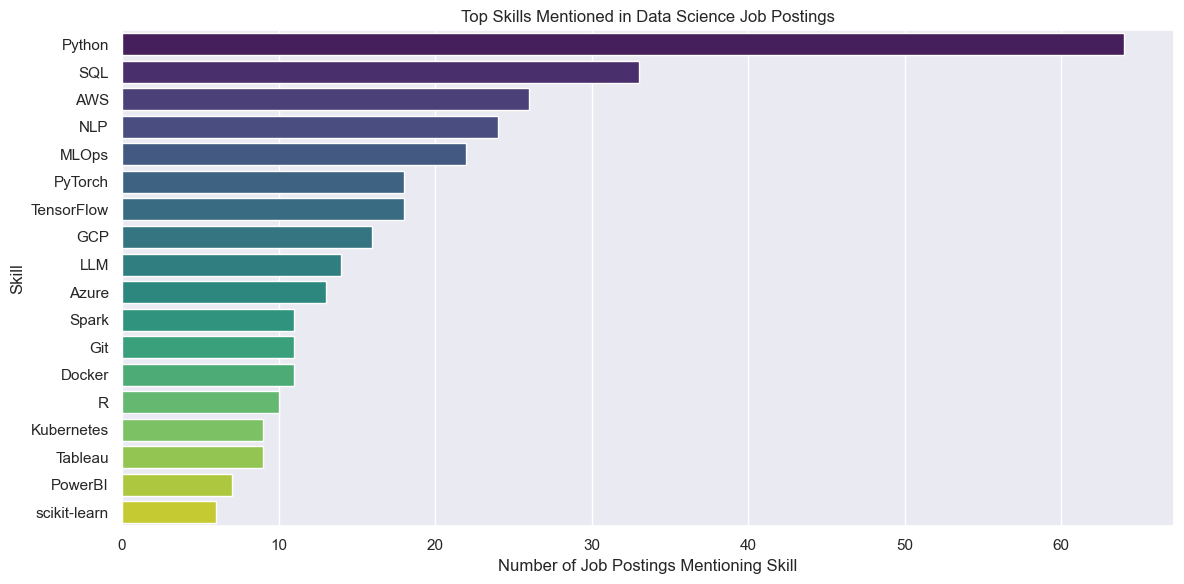

In [31]:
# create a bar chart of the top skills using skills_df
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Skill', data=skills_df,
            hue='Skill', legend=False,
            order=skills_df['Skill'].tolist(), palette='viridis')
plt.title('Top Skills Mentioned in Data Science Job Postings')
plt.xlabel('Number of Job Postings Mentioning Skill')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

## Section 2: Skill Co-occurrence Analysis
Which skills tend to appear together in the same job posting?
Co-occurrence reveals role archetypes hidden in the data.

In [32]:
# Build skill presence matrix - one row per job, one column per skill

skill_names = list(skills.keys())
presence = []

for description in df['job_description']:
    desc_lower = description.lower()
    row = {skill: int(bool(re.search(pattern, desc_lower, re.IGNORECASE)))
           for skill, pattern in skills.items()}
    presence.append(row)

presence_df = pd.DataFrame(presence, columns=skill_names)

# Co-occurrence matrix = presence matrix transposed multiplied by presence matrix
cooccurrence = presence_df.T.dot(presence_df)

print(cooccurrence.shape)
print(cooccurrence.head())

(18, 18)
            Python  SQL   R  PyTorch  TensorFlow  scikit-learn  NLP  AWS  \
Python          64   27  10       17          17             6   15   21   
SQL             27   33   7        6           4             3    6    6   
R               10    7  10        1           1             0    0    3   
PyTorch         17    6   1       18          14             6    9    8   
TensorFlow      17    4   1       14          18             6    9    8   

            Azure  GCP  Docker  Spark  Tableau  PowerBI  Git  MLOps  LLM  \
Python         11   13      11      9        6        4   11     17   11   
SQL             3    5       4      7        8        6    7      3    3   
R               3    3       0      2        4        4    0      0    0   
PyTorch         5    7       6      2        0        0    4      7    5   
TensorFlow      4    5       5      3        1        0    3      9    4   

            Kubernetes  
Python               9  
SQL                  3  
R 

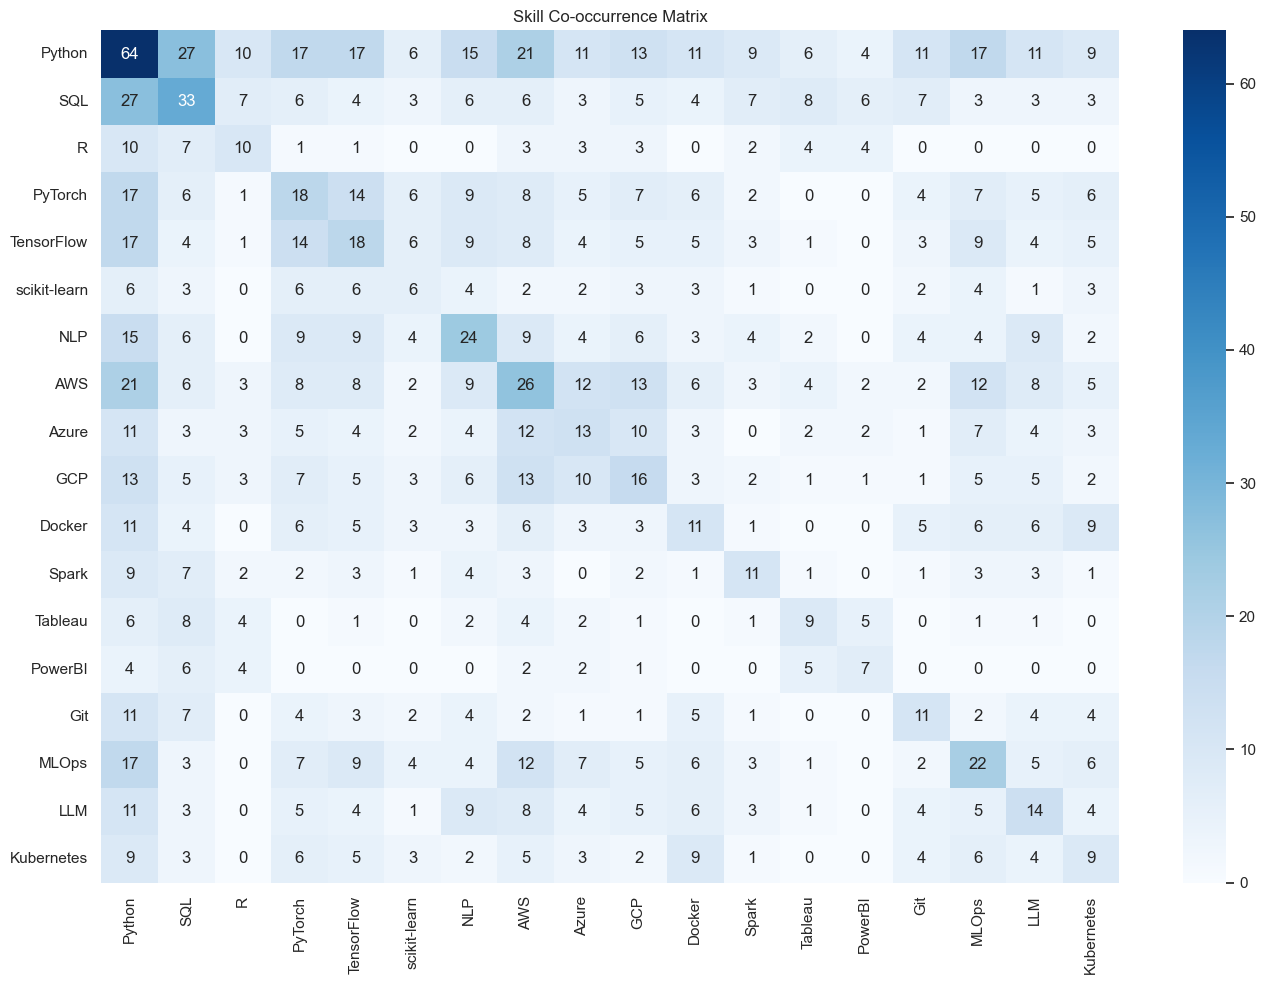

In [33]:
# Co-occurrence heatmap

plt.figure(figsize=(14, 10))
sns.heatmap(cooccurrence,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=skill_names,
            yticklabels=skill_names)
plt.title('Skill Co-occurrence Matrix')
plt.tight_layout()
plt.show()


### Observations
- Python/SQL is the strongest skill pairing — SQL remains essential even in ML roles
- PyTorch and TensorFlow frequently co-occur — employers want deep learning 
  familiarity rather than framework-specific expertise
- MLOps, Docker and Kubernetes cluster together confirming that infrastructure 
  and deployment skills are bundled in employer expectations

## Section 3: Personal Skills Gap Analysis
Mapping current skills against market demand to identify 
priorities for the job transition.

In [35]:
my_skills = { 'Python': 3, 
             'SQL': 1, 
             'AWS': 2, 
             'NLP': 0, 
             'MLOps': 0, 
             'PyTorch': 1, 
             'TensorFlow': 0, 
             'GCP': 0, 
             'LLM': 0, 
             'Azure': 1, 
             'Spark': 1, 
             'Git': 2, 
             'Docker': 0, 
             'R': 2, 
             'Kubernetes': 0, 
             'Tableau': 1, 
             'PowerBI': 1, 
             'scikit-learn': 2 }


# Build gap analysis dataframe
gap_df = skills_df.copy()
gap_df['My Level'] = gap_df['Skill'].map(my_skills)
gap_df['Max_Level'] = 3
gap_df['Gap'] = gap_df['Max_Level'] - gap_df['My Level']

print(gap_df[['Skill', 'Percentage', 'My Level', 'Gap']].to_string())


           Skill  Percentage  My Level  Gap
0         Python        66.7         3    0
1            SQL        34.4         1    2
2            AWS        27.1         2    1
3            NLP        25.0         0    3
4          MLOps        22.9         0    3
5        PyTorch        18.8         1    2
6     TensorFlow        18.8         0    3
7            GCP        16.7         0    3
8            LLM        14.6         0    3
9          Azure        13.5         1    2
10         Spark        11.5         1    2
11           Git        11.5         2    1
12        Docker        11.5         0    3
13             R        10.4         2    1
14    Kubernetes         9.4         0    3
15       Tableau         9.4         1    2
16       PowerBI         7.3         1    2
17  scikit-learn         6.2         2    1


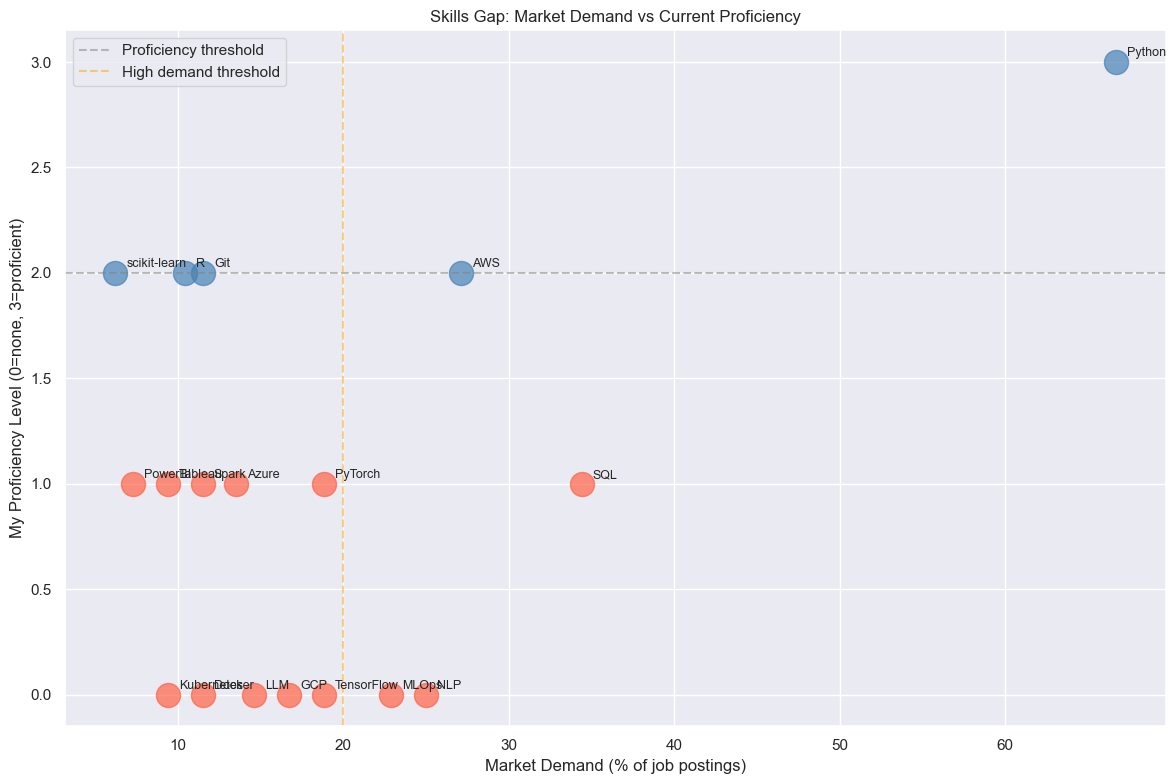

In [38]:
plt.figure(figsize=(12, 8))

for _, row in gap_df.iterrows():
    plt.scatter(row['Percentage'], row['My Level'], 
                s=300, alpha=0.7,
                color='steelblue' if row['My Level'] >= 2 else 'tomato')
    plt.annotate(row['Skill'], 
                (row['Percentage'], row['My Level']),
                textcoords='offset points',
                xytext=(8, 4),
                fontsize=9)

plt.axhline(y=2, color='gray', linestyle='--', alpha=0.5, label='Proficiency threshold')
plt.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='High demand threshold')
plt.xlabel('Market Demand (% of job postings)')
plt.ylabel('My Proficiency Level (0=none, 3=proficient)')
plt.title('Skills Gap: Market Demand vs Current Proficiency')
plt.legend()
plt.tight_layout()
plt.show()

### Observations
- Python is the only skill where proficiency clearly exceeds market demand
- SQL is the highest priority gap — 34% market demand with only basic proficiency
- NLP and MLOps are critical gaps being actively addressed through current projects
- AWS proficiency aligns well with demand — certification renewal would strengthen this
- Infrastructure skills (Docker, Kubernetes, GCP) are lower priority given demand levels

## Section 4: Job Title Analysis
What role titles are employers actually posting for?
Understanding title patterns helps target applications effectively.

In [41]:
# Normalize job titles to identify common patterns
title_patterns = {
    'Data Scientist': r'data scientist',
    'Machine Learning Engineer': r'machine learning engineer',
    'ML Engineer': r'\bml engineer\b',
    'Data Analyst': r'data analyst',
    'NLP Engineer': r'nlp.*engineer|nlp.*ml',
    'MLOps Engineer': r'mlops|ml ops|machine learning operations',
    'Data Engineer': r'data engineer',
    'AI Engineer': r'ai.*engineer|ai.*ml|ai/ml',
    'Research Scientist': r'research scientist',
    'Analytics Manager': r'analytics.*manager|data science manager'
}

title_counts = Counter()

for title in df['job_title']:
    title_lower = title.lower()
    matched = False
    for label, pattern in title_patterns.items():
        if re.search(pattern, title_lower):
            title_counts[label] += 1
            matched = True
            break
    if not matched:
        title_counts['Other'] += 1

title_df = pd.DataFrame(title_counts.items(),
                        columns=['Title', 'Count'])
title_df = title_df.sort_values('Count', ascending=False).reset_index(drop=True)
print(title_df)

                       Title  Count
0             Data Scientist     20
1               Data Analyst     18
2  Machine Learning Engineer     17
3             MLOps Engineer     17
4                ML Engineer     10
5               NLP Engineer      6
6                      Other      4
7                AI Engineer      2
8          Analytics Manager      1
9              Data Engineer      1


In [42]:
# Investigate the Other category
other_titles = []
for title in df['job_title']:
    title_lower = title.lower()
    matched = False
    for label, pattern in title_patterns.items():
        if re.search(pattern, title_lower):
            matched = True
            break
    if not matched:
        other_titles.append(title)

print(f"Total Other: {len(other_titles)}")
print("\nOther titles:")
for t in other_titles:
    print(t)

Total Other: 4

Other titles:
Staff Software Engineer, Machine Learning, Computer Vision
Sr Business Analytics Advisor (US Remote)
Part-time Search Analyst United States (Work From Home)
NLP & Scientific Integrity Post-Doc


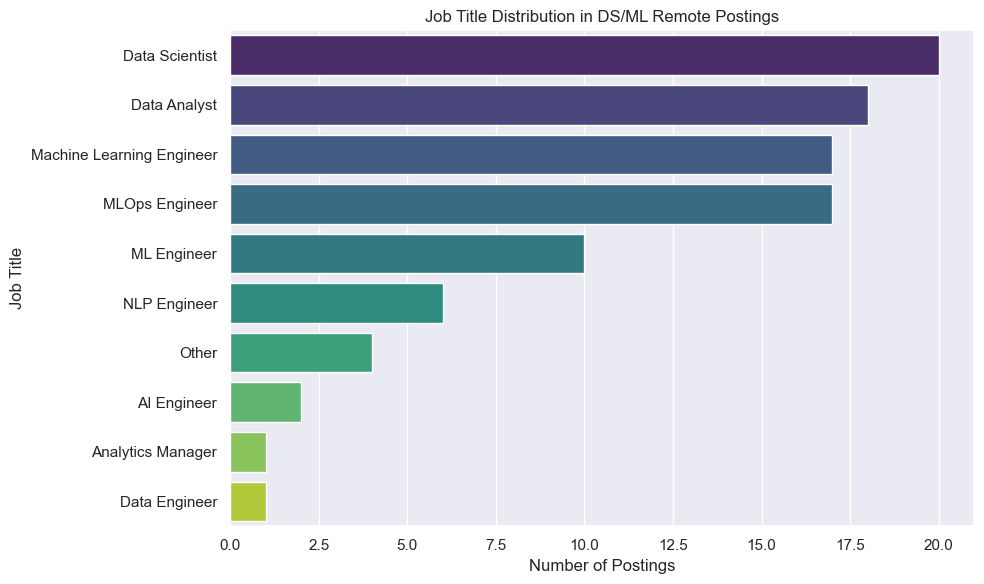

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Title', data=title_df,
            hue='Title', legend=False,
            order=title_df['Title'].tolist(), palette='viridis')
plt.title('Job Title Distribution in DS/ML Remote Postings')
plt.xlabel('Number of Postings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

### Observations
- Data Scientist leads with 20 postings but the gap to other titles is smaller than expected
- MLOps Engineer (17) and ML Engineer (17) combined represent the largest category — 
  production and deployment skills are in high demand
- The market has diversified beyond traditional Data Scientist roles into more 
  specialized engineering-oriented positions
- For job search targeting: Data Scientist is the natural fit given background, 
  but MLOps-adjacent roles represent a growing opportunity worth monitoring

## Section 5: Conclusions & Key Findings

### Market Landscape
Analysis of 96 current remote DS/ML job postings reveals a market that has 
diversified well beyond the traditional Data Scientist title. Nearly 75% of 
postings fall into four roles: Data Scientist, ML Engineer, MLOps Engineer, 
and Data Analyst — with ML and MLOps engineering roles growing rapidly.

### Key Skills Findings
- **Python dominates** at 67% of postings — non-negotiable for any DS/ML role
- **SQL remains critical** at 34% — underestimated by many ML practitioners
- **MLOps and cloud skills** are increasingly bundled expectations, not optional extras
- **LLM experience** appearing in 15% of postings signals rapid market shift 
  toward generative AI

### Personal Skills Gap Priorities
Based on the gap analysis, three areas require immediate focus:
1. **SQL** — highest demand with lowest relative proficiency; quickest addressable gap
2. **NLP** — this project directly contributes to closing this gap
3. **PyTorch** — needs deepening beyond basic exposure given 19% market demand

### Project Impact
Building this project itself contributed to closing the NLP skills gap — 
applying regex-based entity extraction, text analysis, and API data collection 
are all practical NLP techniques. The analysis also produced an actionable, 
data-driven learning roadmap for the job transition.

### Future Extensions
- Expand dataset to 500+ postings for more statistical reliability
- Add salary analysis to correlate compensation with skill combinations
- Build a simple job-match scorer that rates any posting against current skills
- Re-run monthly to track how market demand evolves